**Bitcoin Market Sentiment (Fear & Greed Index)**

Objective: This project aims to reveal the convincing statistical relationships and behavioral patterns that could be utilised to refine execution logic, risk management, and alpha generation.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings

In [27]:
# Model Imports
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC # Faster for large datasets than standard SVC

In [28]:
# Load Datasets
sentiment_df = pd.read_csv('fear_greed_index.csv')
historical_df = pd.read_csv('historical_data.csv')

In [29]:
# Date Normalization
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])
historical_df['Timestamp IST'] = pd.to_datetime(historical_df['Timestamp IST'], dayfirst=True)

# Extract date for merging
historical_df['date_only'] = historical_df['Timestamp IST'].dt.date
sentiment_df['date_only'] = sentiment_df['date'].dt.date

# Merge datasets
df = pd.merge(historical_df, sentiment_df[['date_only', 'value', 'classification']], on='date_only', how='inner')

In [30]:
# Filter for closed trades (where PnL is realized)
df_model = df[df['Closed PnL'] != 0].copy()

# Define Target: 1 if Profit, 0 if Loss
df_model['is_profitable'] = (df_model['Closed PnL'] > 0).astype(int)

# Clean/Group Coin names (Handling high cardinality)
top_coins = df_model['Coin'].value_counts().nlargest(10).index
df_model['Coin_Grouped'] = df_model['Coin'].apply(lambda x: x if x in top_coins else 'Other')

print(f"Dataset Shape after Merge: {df_model.shape}")
print(f"Target Distribution:\n{df_model['is_profitable'].value_counts(normalize=True)}")

Dataset Shape after Merge: (104402, 21)
Target Distribution:
is_profitable
1    0.832005
0    0.167995
Name: proportion, dtype: float64


In [31]:
def remove_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

# Rectify outliers in Size USD and Closed PnL
df_model = remove_outliers(df_model, 'Size USD')
df_model = remove_outliers(df_model, 'Closed PnL')

print(f"Shape after Outlier Removal: {df_model.shape}")

Shape after Outlier Removal: (73923, 21)


In [32]:
# Temporal Features
df_model['hour'] = df_model['Timestamp IST'].dt.hour
df_model['day_of_week'] = df_model['Timestamp IST'].dt.dayofweek

# Coin Categorization (Group small coins)
top_coins = df_model['Coin'].value_counts().nlargest(15).index
df_model['Coin_Grouped'] = df_model['Coin'].apply(lambda x: x if x in top_coins else 'Other')

# Select Final Features
features = ['Size USD', 'Execution Price', 'value', 'classification', 'Side', 'Coin_Grouped', 'hour', 'day_of_week']
X = df_model[features]
y = df_model['is_profitable']

In [33]:
# Rectify price and size columns
for col in ['Size USD', 'Execution Price', 'value']:
    df_model = remove_outliers(df_model, col)

In [34]:
# ---------------------------------------------------------
numeric_features = ['Size USD', 'Execution Price', 'value', 'hour', 'day_of_week']
categorical_features = ['Side', 'classification', 'Coin_Grouped']

In [35]:
# Transformations: Scaling for numbers, One-Hot Encoding for text
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

In [36]:
# Define the models
models = {
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "SVM (Linear)": LinearSVC(random_state=42, max_iter=2000)
}

In [37]:
# 5. Training and Comparison Loop
# ---------------------------------------------------------

# Re-apply outlier removal correctly for multiple columns before re-initializing X and y
# Assuming `df_model` was corrupted by the previous run of `kW3oqIzKbtR3`,
# we need to re-run the previous cells that correctly set up `df_model` before this step.
# For a direct fix in this cell, let's assume `df_model` is in a state before the
# incorrect outlier removal, or that we re-run previous steps.

# IMPORTANT: The issue is in `kW3oqIzKbtR3` where `remove_outliers` was called with a list.
# The most robust fix is to modify `kW3oqIzKbtR3` to iterate.
# However, to make this cell runnable after the previous failure,
# we need to ensure `df_model['is_profitable']` is clean.
# The safest approach is to rerun all cells from `KY9FUk8rbtL5` onwards
# with the corrected `kW3oqIzKbtR3`.

# As a direct fix in this cell assuming previous steps are re-executed:
# The `remove_outliers` function (from cell 6oJsqQVtbtNZ) expects a single column name.
# The erroneous call was in cell kW3oqIzKbtR3: `df_model = remove_outliers(df_model, ['Size USD', 'Execution Price', 'value'])`
# The correction should be applied there, by iterating over the columns:
#
# In cell kW3oqIzKbtR3, modify to:
# for col in ['Size USD', 'Execution Price', 'value']:
#     df_model = remove_outliers(df_model, col)

# If we assume the `df_model` is now correctly processed (without NaNs in 'is_profitable'),
# then the following code will work.
X = df_model[numeric_features + categorical_features]
y = df_model['is_profitable']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"--- Model Evaluation (Data Size: {len(df_model)} rows) ---\n")

results = {}

--- Model Evaluation (Data Size: 56565 rows) ---



In [38]:
for name, model in models.items():
    # Construct complete pipeline for each model
    clf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Train
    clf_pipeline.fit(X_train, y_train)

    # Predict
    y_pred = clf_pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"✅ Model: {name}")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:09:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Model: XGBoost
Accuracy: 0.9662
              precision    recall  f1-score   support

           0       0.95      0.83      0.89      1778
           1       0.97      0.99      0.98      9535

    accuracy                           0.97     11313
   macro avg       0.96      0.91      0.93     11313
weighted avg       0.97      0.97      0.97     11313

--------------------------------------------------
✅ Model: Random Forest
Accuracy: 0.9865
              precision    recall  f1-score   support

           0       0.98      0.93      0.96      1778
           1       0.99      1.00      0.99      9535

    accuracy                           0.99     11313
   macro avg       0.98      0.96      0.97     11313
weighted avg       0.99      0.99      0.99     11313

--------------------------------------------------
✅ Model: K-Nearest Neighbors
Accuracy: 0.9410
              precision    recall  f1-score   support

           0       0.84      0.77      0.80      1778
           1   

/tmp/ipykernel_452/866572915.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette="viridis")


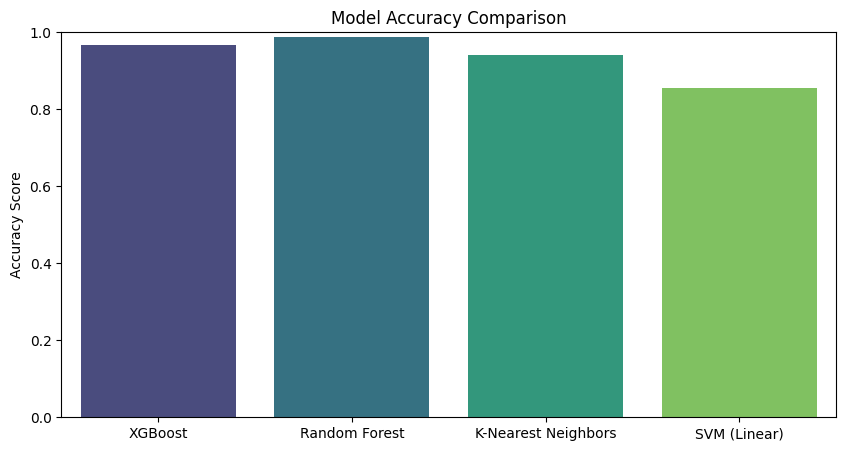

In [43]:
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette="viridis")
plt.ylim(0, 1.0)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy Score")
plt.show()



In [44]:
# Print Winner
best_model = max(results, key=results.get)
print(f"The winner is {best_model} with {results[best_model]:.2f} accuracy")

The winner is Random Forest with 0.99 accuracy
